In [17]:
import numpy as np 
import pandas as pd 

In [18]:
date = pd.read_csv(r"D:\ML\DataSet\orders.csv")
time = pd.read_csv(r"D:\ML\DataSet\messages.csv")

In [19]:
print(date.shape)
print(time.shape)

(1000, 4)
(1000, 2)


In [20]:
date.head()

,date,product_id,city_id,orders
0,2019-12-10,5628,25,3
1,2018-08-15,3646,14,157
2,2018-10-23,1859,25,1
3,2019-08-17,7292,25,1
4,2019-01-06,4344,25,3


In [21]:
time.head()

,date,msg
0,2013-12-15 00:50:00,ищу на сегодня мужика 37
1,2014-04-29 23:40:00,ПАРЕНЬ БИ ИЩЕТ ДРУГА СЕЙЧАС!! СМС ММС 0955532826
2,2012-12-30 00:21:00,Днепр.м 43 позн.с д/ж *.о 067.16.34.576
3,2014-11-28 00:31:00,КИЕВ ИЩУ Д/Ж ДО 45 МНЕ СЕЙЧАС СКУЧНО 093 629 9...
4,2013-10-26 23:11:00,Зая я тебя никогда не обижу люблю тебя!) Даше


as we know that date and time in pandas will behave as a string , so, we have to solve that issue.

## Working with Dates

In [22]:
# Converting to datetime datatype
date['date'] = pd.to_datetime(date['date'])

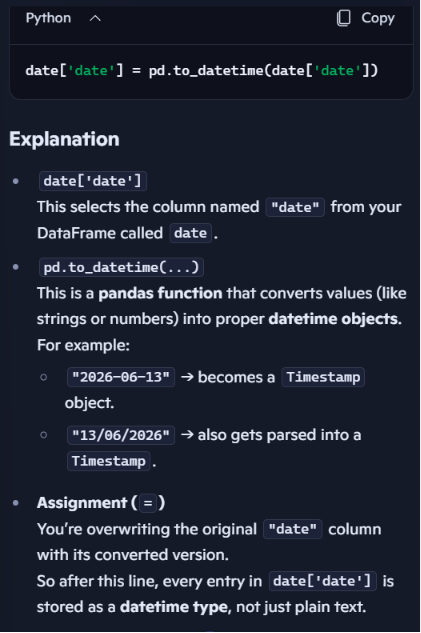

In [23]:
date.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        1000 non-null   datetime64[us]
 1   product_id  1000 non-null   int64         
 2   city_id     1000 non-null   int64         
 3   orders      1000 non-null   int64         
dtypes: datetime64[us](1), int64(3)
memory usage: 31.4 KB


### 1. Extracting the Year

In [24]:
date['date_year'] = date['date'].dt.year        #dt = dateTime
#learn the code, important for extractionn of the year or month or day

In [25]:
date.head()

,date,product_id,city_id,orders,date_year
0,2019-12-10,5628,25,3,2019
1,2018-08-15,3646,14,157,2018
2,2018-10-23,1859,25,1,2018
3,2019-08-17,7292,25,1,2019
4,2019-01-06,4344,25,3,2019


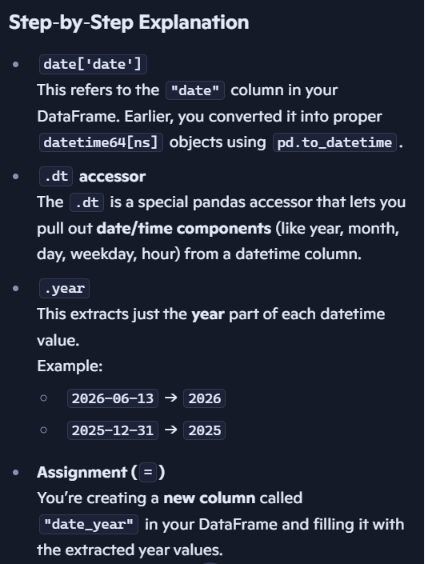

In [26]:
date['date_month_no.'] = date['date'].dt.month

#here, the ".month" is  the attribute but if we wanted to get the name of the month then we have to use a function

date.sample(3)


,date,product_id,city_id,orders,date_year,date_month_no.
525,2019-06-13,2249,20,2,2019,6
163,2018-11-12,2541,28,4,2018,11
502,2019-06-19,1232,14,8,2019,6


In [27]:
date['date_month_name'] = date['date'].dt.month_name()
date.sample(3)

,date,product_id,city_id,orders,date_year,date_month_no.,date_month_name
976,2019-04-18,5320,13,1,2019,4,April
614,2018-08-14,5941,25,2,2018,8,August
313,2018-12-29,5118,13,125,2018,12,December


Extract Days

In [28]:
date['date_day']  = date['date'].dt.day
date.sample(3)

,date,product_id,city_id,orders,date_year,date_month_no.,date_month_name,date_day
907,2019-08-13,5073,13,1,2019,8,August,13
547,2019-06-21,793,29,3,2019,6,June,21
328,2019-11-20,7467,23,2,2019,11,November,20


In [29]:
date['date_day_name'] = date['date'].dt.day_name()
date.sample(3)

,date,product_id,city_id,orders,date_year,date_month_no.,date_month_name,date_day,date_day_name
1,2018-08-15,3646,14,157,2018,8,August,15,Wednesday
539,2019-12-08,2831,16,4,2019,12,December,8,Sunday
566,2019-04-29,3646,14,63,2019,4,April,29,Monday


In [30]:
# day of week - it's indexing is from 0 i.e. monday have day = 0

date['date_dayOfWeek'] = date['date'].dt.day_of_week
date.head(3)

,date,product_id,city_id,orders,date_year,date_month_no.,date_month_name,date_day,date_day_name,date_dayOfWeek
0,2019-12-10,5628,25,3,2019,12,December,10,Tuesday,1
1,2018-08-15,3646,14,157,2018,8,August,15,Wednesday,2
2,2018-10-23,1859,25,1,2018,10,October,23,Tuesday,1


In [33]:
#is weekend?

date['date_is_weekend'] = np.where(date['date_day_name'].isin(['Sunday','Saturday']),1,0)
date.head()

,date,product_id,city_id,orders,date_year,date_month_no.,date_month_name,date_day,date_day_name,date_dayOfWeek,date_is_weekend
0,2019-12-10,5628,25,3,2019,12,December,10,Tuesday,1,0
1,2018-08-15,3646,14,157,2018,8,August,15,Wednesday,2,0
2,2018-10-23,1859,25,1,2018,10,October,23,Tuesday,1,0
3,2019-08-17,7292,25,1,2019,8,August,17,Saturday,5,1
4,2019-01-06,4344,25,3,2019,1,January,6,Sunday,6,1


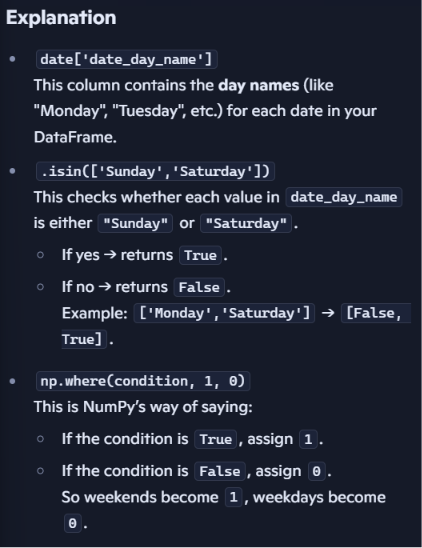

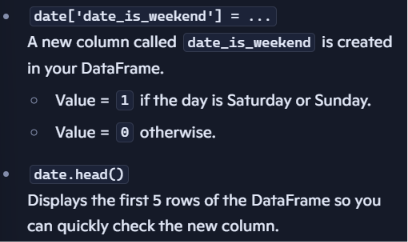

### Extract week of the Year

In [34]:
date['date_week'] = date['date'].dt.week        #this was in old version. in newer one it doesn't works
date.head()

AttributeError: 'DatetimeProperties' object has no attribute 'week'

In [35]:
date['date_week'] = date['date'].dt.isocalendar().week
date.head()

,date,product_id,city_id,orders,date_year,date_month_no.,date_month_name,date_day,date_day_name,date_dayOfWeek,date_is_weekend,date_week
0,2019-12-10,5628,25,3,2019,12,December,10,Tuesday,1,0,50
1,2018-08-15,3646,14,157,2018,8,August,15,Wednesday,2,0,33
2,2018-10-23,1859,25,1,2018,10,October,23,Tuesday,1,0,43
3,2019-08-17,7292,25,1,2019,8,August,17,Saturday,5,1,33
4,2019-01-06,4344,25,3,2019,1,January,6,Sunday,6,1,1


In [36]:
date['date_quater'] = date['date'].dt.quarter
date.head()

,date,product_id,city_id,orders,date_year,date_month_no.,date_month_name,date_day,date_day_name,date_dayOfWeek,date_is_weekend,date_week,date_quater
0,2019-12-10,5628,25,3,2019,12,December,10,Tuesday,1,0,50,4
1,2018-08-15,3646,14,157,2018,8,August,15,Wednesday,2,0,33,3
2,2018-10-23,1859,25,1,2018,10,October,23,Tuesday,1,0,43,4
3,2019-08-17,7292,25,1,2019,8,August,17,Saturday,5,1,33,3
4,2019-01-06,4344,25,3,2019,1,January,6,Sunday,6,1,1,1


Exact Semester

In [37]:
date['date_semester'] = np.where(date['date_quater'].isin([1,2]),1,2)
date.head()

,date,product_id,city_id,orders,date_year,date_month_no.,date_month_name,date_day,date_day_name,date_dayOfWeek,date_is_weekend,date_week,date_quater,date_semester
0,2019-12-10,5628,25,3,2019,12,December,10,Tuesday,1,0,50,4,2
1,2018-08-15,3646,14,157,2018,8,August,15,Wednesday,2,0,33,3,2
2,2018-10-23,1859,25,1,2018,10,October,23,Tuesday,1,0,43,4,2
3,2019-08-17,7292,25,1,2019,8,August,17,Saturday,5,1,33,3,2
4,2019-01-06,4344,25,3,2019,1,January,6,Sunday,6,1,1,1,1


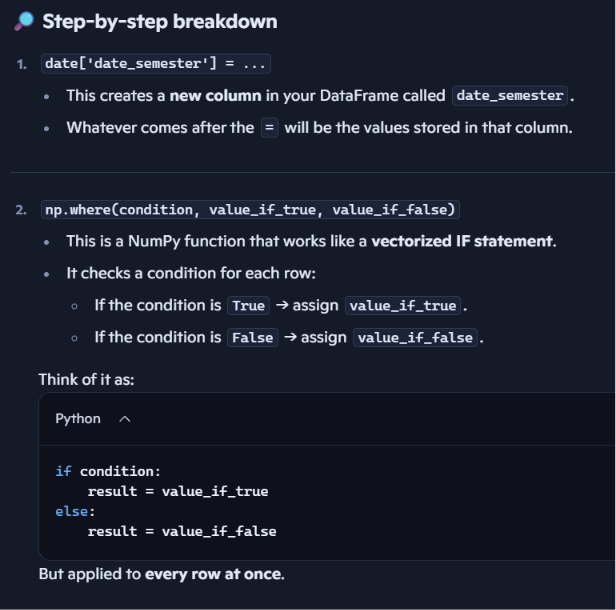
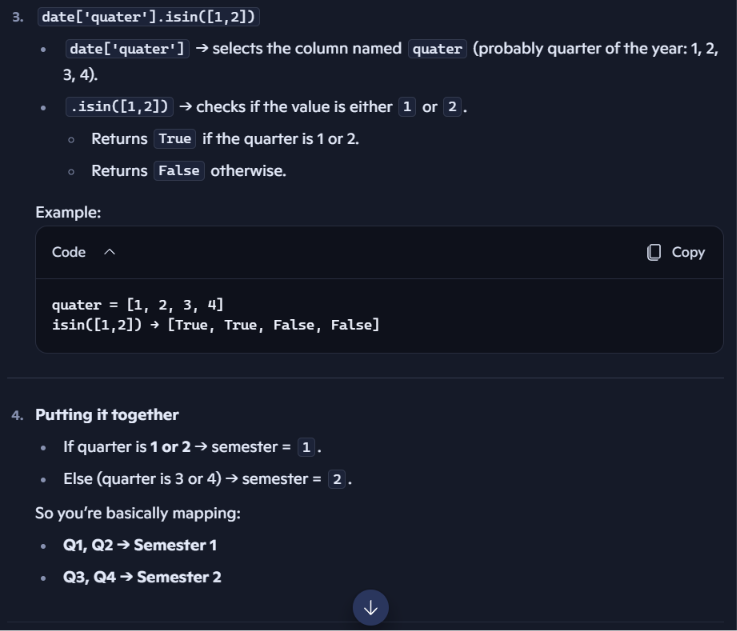


now if we wanted to get time between 2 dates then we do the following things

In [42]:
import datetime

today = pd.Timestamp(datetime.datetime.today())

today

Timestamp('2026-06-14 10:08:54.794878')

In [43]:
today - date["date"]

0     2378 days 10:08:54.794878
1     2860 days 10:08:54.794878
2     2791 days 10:08:54.794878
3     2493 days 10:08:54.794878
4     2716 days 10:08:54.794878
                 ...           
995   2806 days 10:08:54.794878
996   2747 days 10:08:54.794878
997   2595 days 10:08:54.794878
998   2660 days 10:08:54.794878
999   2434 days 10:08:54.794878
Name: date, Length: 1000, dtype: timedelta64[us]

In [44]:
#if we just wanted days then run the following code
(today - date["date"]).dt.days

0      2378
1      2860
2      2791
3      2493
4      2716
       ... 
995    2806
996    2747
997    2595
998    2660
999    2434
Name: date, Length: 1000, dtype: int64

In [46]:
# Months passed - this code works in new version of pandas.

months_passed = (today.to_period('M') - date['date'].dt.to_period('M'))
months_passed

0      <78 * MonthEnds>
1      <94 * MonthEnds>
2      <92 * MonthEnds>
3      <82 * MonthEnds>
4      <89 * MonthEnds>
             ...       
995    <92 * MonthEnds>
996    <90 * MonthEnds>
997    <85 * MonthEnds>
998    <87 * MonthEnds>
999    <80 * MonthEnds>
Name: date, Length: 1000, dtype: object

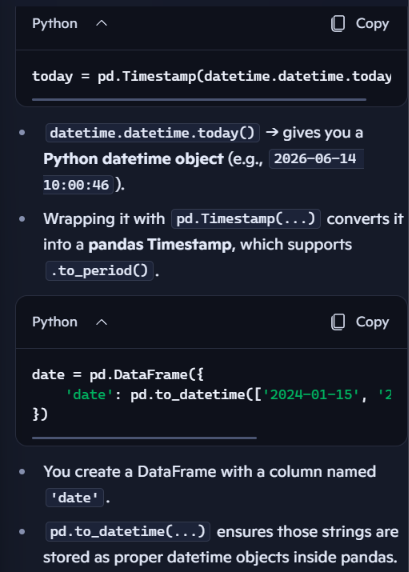
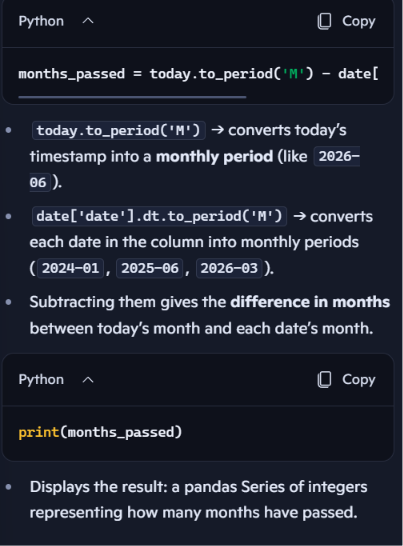

In [ ]:
months_passed = np.round((today-date['date'])/np.timedelta64(1,'M'),0)
months_passed

#month from support is removed . Allowed measurements are 'W', 'D', 'h', 'm', 's', 'ms', 'us', 'ns'

ValueError: Unit M is not supported. Only unambiguous timedelta values durations are supported. Allowed units are 'W', 'D', 'h', 'm', 's', 'ms', 'us', 'ns'

In [49]:
months_passed = np.round((today-date['date'])/np.timedelta64(1,'ns'),0)
months_passed

0      2.054957e+17
1      2.471405e+17
2      2.411789e+17
3      2.154317e+17
4      2.346989e+17
           ...     
995    2.424749e+17
996    2.373773e+17
997    2.242445e+17
998    2.298605e+17
999    2.103341e+17
Name: date, Length: 1000, dtype: float64

---
---

## time

In [50]:
time.head()

,date,msg
0,2013-12-15 00:50:00,ищу на сегодня мужика 37
1,2014-04-29 23:40:00,ПАРЕНЬ БИ ИЩЕТ ДРУГА СЕЙЧАС!! СМС ММС 0955532826
2,2012-12-30 00:21:00,Днепр.м 43 позн.с д/ж *.о 067.16.34.576
3,2014-11-28 00:31:00,КИЕВ ИЩУ Д/Ж ДО 45 МНЕ СЕЙЧАС СКУЧНО 093 629 9...
4,2013-10-26 23:11:00,Зая я тебя никогда не обижу люблю тебя!) Даше


In [51]:
time.info() #here also the date column is in object format. We have to convert it into datetime format.

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   date    1000 non-null   str  
 1   msg     1000 non-null   str  
dtypes: str(2)
memory usage: 15.8 KB


In [52]:
time['date'] = pd.to_datetime(time['date'])

In [53]:
time.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    1000 non-null   datetime64[us]
 1   msg     1000 non-null   str           
dtypes: datetime64[us](1), str(1)
memory usage: 15.8 KB


In [54]:
time['hour'] = time['date'].dt.hour
time['minute']= time['date'].dt.minute
time['second'] = time['date'].dt.second

time.head()

,date,msg,hour,minute,second
0,2013-12-15 00:50:00,ищу на сегодня мужика 37,0,50,0
1,2014-04-29 23:40:00,ПАРЕНЬ БИ ИЩЕТ ДРУГА СЕЙЧАС!! СМС ММС 0955532826,23,40,0
2,2012-12-30 00:21:00,Днепр.м 43 позн.с д/ж *.о 067.16.34.576,0,21,0
3,2014-11-28 00:31:00,КИЕВ ИЩУ Д/Ж ДО 45 МНЕ СЕЙЧАС СКУЧНО 093 629 9...,0,31,0
4,2013-10-26 23:11:00,Зая я тебя никогда не обижу люблю тебя!) Даше,23,11,0


In [56]:
time['time'] = time['date'].dt.time
time.head()

,date,msg,hour,minute,second,time
0,2013-12-15 00:50:00,ищу на сегодня мужика 37,0,50,0,00:50:00
1,2014-04-29 23:40:00,ПАРЕНЬ БИ ИЩЕТ ДРУГА СЕЙЧАС!! СМС ММС 0955532826,23,40,0,23:40:00
2,2012-12-30 00:21:00,Днепр.м 43 позн.с д/ж *.о 067.16.34.576,0,21,0,00:21:00
3,2014-11-28 00:31:00,КИЕВ ИЩУ Д/Ж ДО 45 МНЕ СЕЙЧАС СКУЧНО 093 629 9...,0,31,0,00:31:00
4,2013-10-26 23:11:00,Зая я тебя никогда не обижу люблю тебя!) Даше,23,11,0,23:11:00


### Time Difference

In [57]:
today - time['date']

0     4564 days 09:18:54.794878
1     4428 days 10:28:54.794878
2     4914 days 09:47:54.794878
3     4216 days 09:37:54.794878
4     4613 days 10:57:54.794878
                 ...           
995   5203 days 09:18:54.794878
996   4524 days 10:54:54.794878
997   4989 days 10:31:54.794878
998   5105 days 10:34:54.794878
999   4377 days 10:43:54.794878
Name: date, Length: 1000, dtype: timedelta64[us]

In [59]:
#in seconds

((today-time['date'])/np.timedelta64(1,'s'))

0      3.943631e+08
1      3.826169e+08
2      4.246049e+08
3      3.642971e+08
4      3.986027e+08
           ...     
995    4.495727e+08
996    3.909129e+08
997    4.310875e+08
998    4.411101e+08
999    3.782114e+08
Name: date, Length: 1000, dtype: float64

In [60]:
#in minutes

((today-time['date'])/np.timedelta64(1,'m'))

0      6.572719e+06
1      6.376949e+06
2      7.076748e+06
3      6.071618e+06
4      6.643378e+06
           ...     
995    7.492879e+06
996    6.515215e+06
997    7.184792e+06
998    7.351835e+06
999    6.303524e+06
Name: date, Length: 1000, dtype: float64

In [61]:
#in hours

((today-time['date'])/np.timedelta64(1,'h'))

0      109545.315221
1      106282.481887
2      117945.798554
3      101193.631887
4      110722.965221
           ...      
995    124881.315221
996    108586.915221
997    119746.531887
998    122530.581887
999    105058.731887
Name: date, Length: 1000, dtype: float64

-------
mainly useful when we are dealing with timezones